#### The separation distirbutions of the binary white dwarf (WDWD) and binary neutron star (NSNS) systems that merge within a Hubble Time and their progenitors

### Imports and definitions

In [1]:
import h5py as h5 
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import tol_colors as tc

import useful_fncs
import utils_from_others
import figure_utils

# plotting imports
# import for axes labels 
plt.rc('text.latex', preamble=r'\usepackage{textgreek}')
plt.rc('font', family='serif')
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "sans-serif"
})

### Read in Data

We are going to start with reading in data about the WDWD systems that could possibly represent the double degenerate scenario of Type Ia Supernovae. We will use the WDWD optimized run to gather this information. Our conditions for the general double degenerate case is:

1) two white dwarfs, with at least being a carbon/oxygen WD (COWD)
2) merge within a Hubble Time

In [2]:
## WDWD optimized run
pathToH5_WDWD = '/expanse/lustre/scratch/msantiago/temp_project/COMPAS_DATA/N5e6_MassiveWDWD_NSNS_fid/MainRun/COMPAS_Output_wWeights.h5'

Data_WDWD  = h5.File(pathToH5_WDWD, "r")

DCOs_WDWD = Data_WDWD['BSE_Double_Compact_Objects'] # getting the DCO objects

# gathering the double compact objects that we have computed rates for
DCO_mask_WDWD = Data_WDWD['Rates_mu00.025_muz-0.049_alpha-1.79_sigma01.129_sigmaz0.048']['DCOmask'][()]

DATA_SPS_WDWD = Data_WDWD['BSE_System_Parameters']

In [3]:
# merging conditions
Merges_Hubble_Time_WDopt = Data_WDWD['BSE_Double_Compact_Objects']['Merges_Hubble_Time'][()]
Merges_Hubble_Time_DCO_WDopt = Merges_Hubble_Time_WDopt[DCO_mask_WDWD]
condition_mergers_WDopt = Merges_Hubble_Time_DCO_WDopt == True

stellar_types_all_1_WDopt = DCOs_WDWD['Stellar_Type(1)'][()]
stellar_types_1_DCO_WDopt = stellar_types_all_1_WDopt[DCO_mask_WDWD]
stellar_types_1_merged_WDopt = stellar_types_1_DCO_WDopt[condition_mergers_WDopt]

stellar_types_all_2 = DCOs_WDWD['Stellar_Type(2)'][()]
stellar_types_2_DCO = stellar_types_all_2[DCO_mask_WDWD]
stellar_types_2_merged_WDopt = stellar_types_2_DCO[condition_mergers_WDopt]

stellar_types_all_1_WDopt = DCOs_WDWD['Stellar_Type(1)'][()]
stellar_types_1_DCO_WDopt = stellar_types_all_1_WDopt[DCO_mask_WDWD]
stellar_types_1_merged_WDopt = stellar_types_1_DCO_WDopt[condition_mergers_WDopt]

# gathering the masses
mass_1_all = DCOs_WDWD['Mass(1)'][()]
mass_1_DCO = mass_1_all[DCO_mask_WDWD]
mass_1_merged = mass_1_DCO[condition_mergers_WDopt]

mass_2_all = DCOs_WDWD['Mass(2)'][()]
mass_2_DCO = mass_2_all[DCO_mask_WDWD]
mass_2_merged = mass_2_DCO[condition_mergers_WDopt]

# we are going to conditions that M1>M2 (not considering mass ratio reversal cases)
M1 = np.maximum(mass_1_merged, mass_2_merged)
M2 = np.minimum(mass_1_merged, mass_2_merged)

# gathering the mixture weight info
mixture_weights_all_WDopt = DCOs_WDWD['mixture_weight'][()]
mixtrue_weights_dco_WDopt = mixture_weights_all_WDopt[DCO_mask_WDWD]
mixtrue_weights_merged_WDopt = mixtrue_weights_dco_WDopt[condition_mergers_WDopt]

In [4]:
# let's find the bools for each of our progenitor systems

# WDWD bool with at least one COWD + COWD/HeWD
HeWD_bool_WDWD,COWD_bool_WDWD,ONeWD_bool_WDWD,HeCOWD_bool_WDWD,HeONeWD_bool_WDWD,COHeWD_bool_WDWD,COONeWD_bool_WDWD,ONeHeWD_bool_WDWD,ONeCOWD_bool_WDWD = useful_fncs.WD_BINARY_BOOLS(stellar_types_1_merged_WDopt, stellar_types_2_merged_WDopt)
carbon_oxygen_bool_WDWD_merged_WDopt = np.logical_or(COHeWD_bool_WDWD, np.logical_or(COWD_bool_WDWD, HeCOWD_bool_WDWD))

# violent merger - unequal mass + COWD+COWD
mass_unequal_conditon = mass_1_merged >= 1.0
violent_merger_unequal_bool = mass_unequal_conditon*COWD_bool_WDWD

# violent merger - equal mass (q_cr = 0.9) + COWD+COWD
critical_mass_ratio_bool = M2/M1 >= 0.9
violent_merger_equal_bool = critical_mass_ratio_bool*COWD_bool_WDWD

# D6 HVS
SN_Ia_HVS,two_star_SNIA,Champagne_Supernova = useful_fncs.check_if_SNIA(mass_1_merged, mass_2_merged)

# D6 - two explosion
mass_D6_condition = mass_1_merged < 1.0
d6_two_explosion = mass_D6_condition*carbon_oxygen_bool_WDWD_merged_WDopt


In [5]:
rates_z0_DCO = Data_WDWD['Rates_mu00.025_muz-0.049_alpha-1.79_sigma01.129_sigmaz0.048']['merger_rate_z0'][()]
rates_z0_merged = rates_z0_DCO[condition_mergers_WDopt]
rates_z0_merged_COWD = rates_z0_merged[carbon_oxygen_bool_WDWD_merged_WDopt]

In [6]:
rates_z0_violent_merger_unequal = rates_z0_merged[violent_merger_unequal_bool]
rates_z0_violent_merger_equal = rates_z0_merged[violent_merger_equal_bool]
rates_z0_HVS = rates_z0_merged[SN_Ia_HVS]
rates_z0_D6_twoexplosion = rates_z0_merged[d6_two_explosion]

### Plotting

Text(0.5, 1.0, 'Mass Distribution')

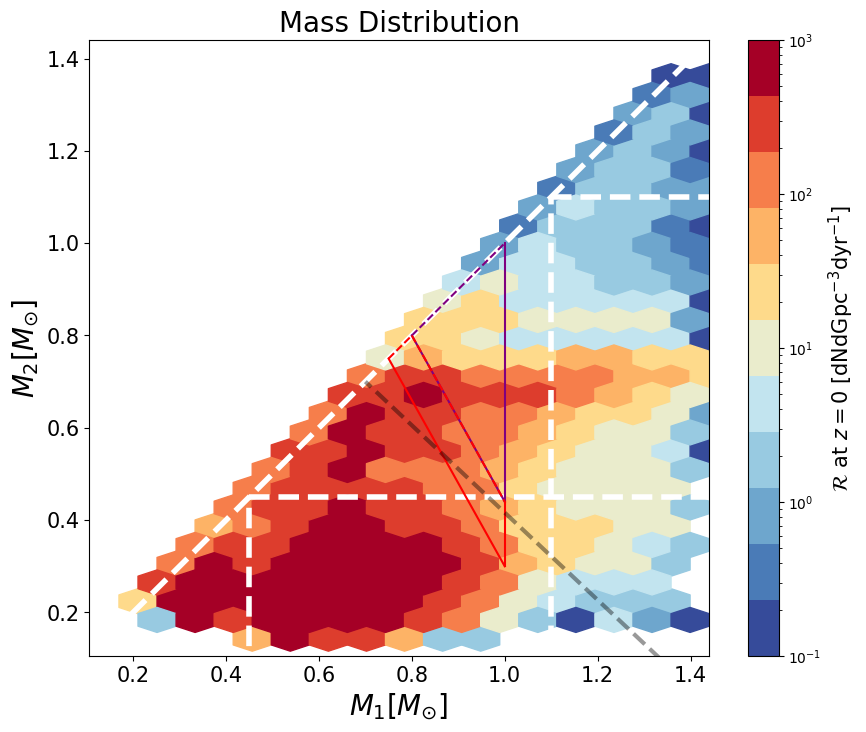

In [9]:
fig, ax = plt.subplots(figsize = (10,8))

# cset = tc.sunset_


vmin = 10**-1
vmax = 10**3

M1_COWD = M1[carbon_oxygen_bool_WDWD_merged_WDopt]
M2_COWD = M2[carbon_oxygen_bool_WDWD_merged_WDopt]

hb = ax.hexbin(M1_COWD,M2_COWD,C=rates_z0_merged_COWD, gridsize=(15,15), reduce_C_function = np.sum, 
                    cmap="tol.sunset_discrete",norm='log',vmin=vmin,vmax=vmax) # C is how much each point is weighted

cb = plt.colorbar(hb)
cb.set_label(label=r"$\mathcal{R}$ at $z=0$ [$\mathrm{dNdGpc^{-3}dyr^{-1}}$]", fontsize = 15)

max_mass_lim = 1.44

linecolors = 'white'
linewidths = 4

ax.axline((0,0), (max(M1),max(M1)), color=linecolors, ls='--', lw=linewidths, transform=plt.gca().transAxes)

#Helium WD cutoff
ax.vlines(x=[0.45], ymin=0, ymax=0.45, colors=linecolors, ls='--', lw=linewidths) # vertical line
ax.plot([0.45,max_mass_lim],[0.45,0.45],color=linecolors,lw=linewidths, ls='--') # horizontal line

#Carbon oxygen WD cutoff
ax.vlines(x=[1.1], ymin=0, ymax=1.1, colors=linecolors, ls='--', lw=linewidths) # vertical line
ax.plot([1.1,max_mass_lim],[1.1,1.1],color=linecolors,lw=linewidths, ls='--') # horizontal line

# purple region - 2 star SN Ia
ax.plot([0.8,1],[0.8,0.44],color='purple') # bottom boundary
ax.plot([1.0,1.0],[1.0,0.44],color='purple') # side boundary
ax.plot([0.8,1.0],[0.8,1.0],color='purple',ls='--') # top boundary 

# red region - hypervelocity WDs
plt.plot([0.8,1],[0.8,0.44],color='red',ls='--') # overlapping boundary
plt.plot([0.75,1.0],[0.75,0.3],color='red') # bottom boundary
plt.plot([1.0,1.0],[0.3,0.44],color='red') # side boundary
plt.plot([0.75,0.8],[0.75,0.8],color='red',ls='--') # top boundary

# # chandrasekar mass line
ax.plot((1.44,0.7),(0,0.7),color='black', lw=3, ls='--', alpha = 0.4)

ax.set_ylim(min(M2),max_mass_lim)
ax.set_xlim(min(M2),max_mass_lim)
ax.set_xlabel("$M_{1}$[$M_{\odot}$]",fontsize=20)
ax.set_ylabel("$M_{2}$[$M_{\odot}$]",fontsize=20)
ax.tick_params(axis='both', labelsize=15)

ax.set_title("Mass Distribution", fontsize=20)

## save figure:
# plt.savefig("../figures/mass_dist_scenarios.png",bbox_inches='tight',pad_inches=0.1)

Let's look at what this mass distribution looks like when we don't instill M1>M2

Text(0, 0.5, '$M_{2}$[$M_{\\odot}$]')

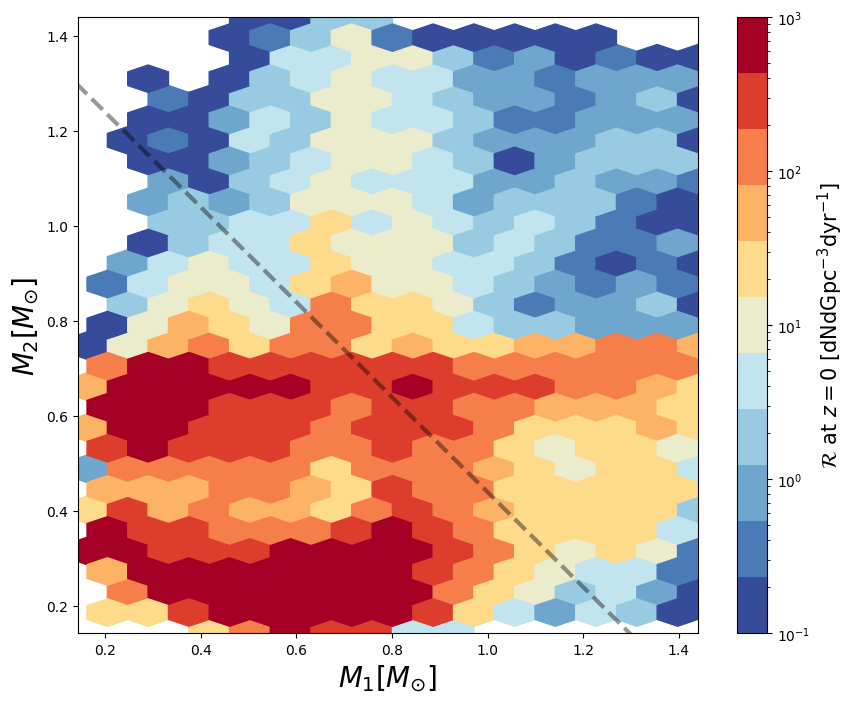

In [9]:
fig, ax = plt.subplots(figsize = (10,8))

# cset = tc.sunset_


vmin = 10**-1
vmax = 10**3

hb = ax.hexbin(mass_1_COWD_WDopt,mass_2_COWD_WDopt,C=rates_z0_merged_COWD, gridsize=(15,15), reduce_C_function = np.sum, 
                    cmap="tol.sunset_discrete",norm='log',vmin=vmin,vmax=vmax) # C is how much each point is weighted

cb = plt.colorbar(hb)
cb.set_label(label=r"$\mathcal{R}$ at $z=0$ [$\mathrm{dNdGpc^{-3}dyr^{-1}}$]", fontsize = 15)

max_mass_lim = 1.44

# # chandrasekar mass line
ax.plot((1.44,0),(0,1.44),color='black', lw=3, ls='--', alpha = 0.4)

ax.set_ylim(min(mass_2_COWD_WDopt),max_mass_lim)
ax.set_xlim(min(mass_2_COWD_WDopt),max_mass_lim)
ax.set_xlabel("$M_{1}$[$M_{\odot}$]",fontsize=20)
ax.set_ylabel("$M_{2}$[$M_{\odot}$]",fontsize=20)

Let's also look at the one dimensional histograms of the mass

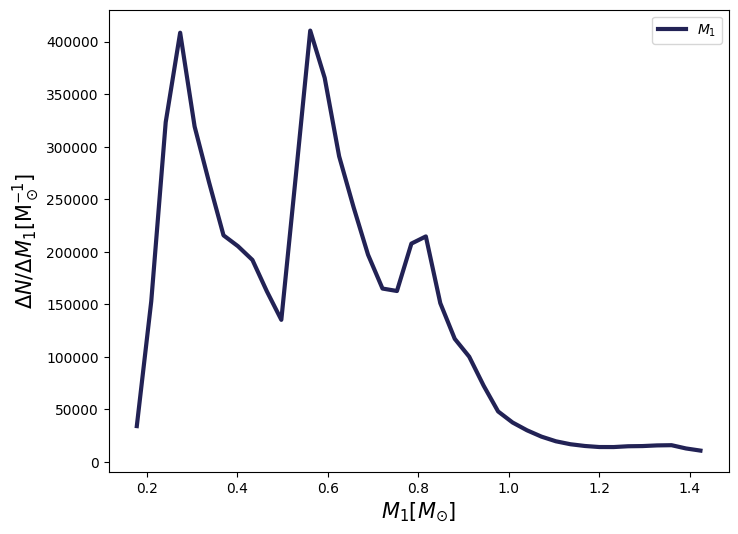

In [15]:
# plotting formation efficencies

fig, axs = plt.subplots(figsize=(8, 6))
cset = tc.dark

hist_COWD_M1, bin_edges_COWD_M1 = np.histogram(mass_1_COWD_WDopt, weights=mixture_weights_COWD, bins=40, density=False)

bin_centers_COWD_M1 = (bin_edges_COWD_M1[0:-1] + bin_edges_COWD_M1[1:])/2
bin_widths_COWD_M1 = np.diff(bin_edges_COWD_M1)

# plotting
axs.plot(bin_centers_COWD_M1, hist_COWD_M1/bin_widths_COWD_M1,color=cset.dark_blue, lw=3, label="$M_1$")


axs.set_ylabel(r'$\mathrm{\Delta}N/\mathrm{\Delta}M_1[\mathrm{M_\odot^{-1}}]$', fontsize=15)
axs.set_xlabel(r'$M_{1}$[$M_{\odot}$]', fontsize=15)
axs.legend()

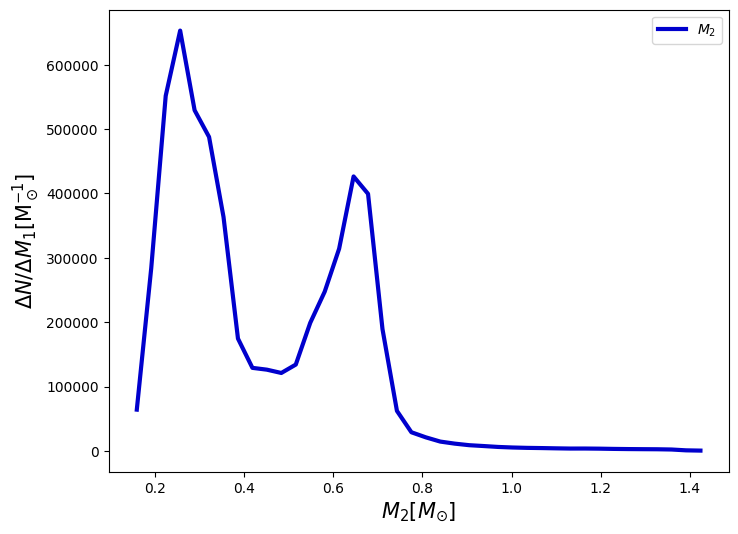

In [16]:
# plotting formation efficencies

fig, axs = plt.subplots(figsize=(8, 6))
cset = tc.dark

hist_COWD_M2, bin_edges_COWD_M2 = np.histogram(mass_2_COWD_WDopt, weights=mixture_weights_COWD, bins=40, density=False)

bin_centers_COWD_M2 = (bin_edges_COWD_M2[0:-1] + bin_edges_COWD_M2[1:])/2
bin_widths_COWD_M2 = np.diff(bin_edges_COWD_M2)

# plotting
axs.plot(bin_centers_COWD_M2, hist_COWD_M2/bin_widths_COWD_M2,color='mediumblue', lw=3, label='$M_2$')


axs.set_ylabel(r'$\mathrm{\Delta}N/\mathrm{\Delta}M_1[\mathrm{M_\odot^{-1}}]$', fontsize=15)
axs.set_xlabel(r'$M_{2}$[$M_{\odot}$]', fontsize=15)
axs.legend()

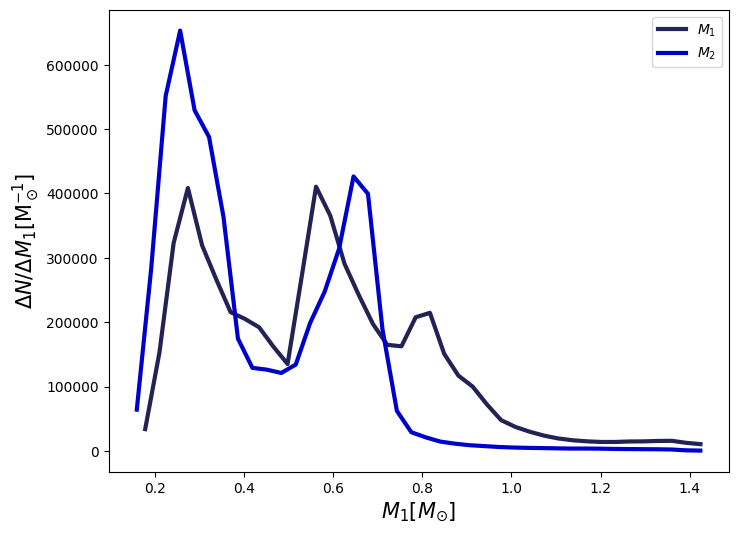

In [17]:
# plotting formation efficencies

fig, axs = plt.subplots(figsize=(8, 6))
cset = tc.dark

hist_COWD_M1, bin_edges_COWD_M1 = np.histogram(mass_1_COWD_WDopt, weights=mixture_weights_COWD, bins=40, density=False)

bin_centers_COWD_M1 = (bin_edges_COWD_M1[0:-1] + bin_edges_COWD_M1[1:])/2
bin_widths_COWD_M1 = np.diff(bin_edges_COWD_M1)

# plotting
axs.plot(bin_centers_COWD_M1, hist_COWD_M1/bin_widths_COWD_M1,color=cset.dark_blue, lw=3, label="$M_1$")

hist_COWD_M2, bin_edges_COWD_M2 = np.histogram(mass_2_COWD_WDopt, weights=mixture_weights_COWD, bins=40, density=False)

bin_centers_COWD_M2 = (bin_edges_COWD_M2[0:-1] + bin_edges_COWD_M2[1:])/2
bin_widths_COWD_M2 = np.diff(bin_edges_COWD_M2)

# plotting
axs.plot(bin_centers_COWD_M2, hist_COWD_M2/bin_widths_COWD_M2,color='mediumblue', lw=3, label='$M_2$')

axs.set_ylabel(r'$\mathrm{\Delta}N/\mathrm{\Delta}M_1[\mathrm{M_\odot^{-1}}]$', fontsize=15)
axs.set_xlabel(r'$M_{1}$[$M_{\odot}$]', fontsize=15)
axs.legend()